# Task 2B — QLoRA fine-tuning (Colab T4)
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/krishanSKDA/CDAZZDEV-MLE-Krishan_Danushka/blob/main/task2_genai/Task2_FineTune.ipynb)

Runtime → Change runtime type → **T4 GPU**. Needs `HF_TOKEN` (write) in Colab Secrets; `WANDB_API_KEY` optional.

In [1]:
!git -C /content/repo pull

Already up to date.


In [2]:
import os, sys, subprocess

REPO_URL = "https://github.com/krishanSKDA/CDAZZDEV-MLE-Krishan_Danushka.git"
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("/content/repo"):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, "/content/repo"], check=True)
    os.chdir("/content/repo")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "task2_genai/requirements-train.txt"], check=True)
else:
    while not os.path.exists("requirements.txt"):
        os.chdir("..")
sys.path.insert(0, os.getcwd())
print("repo root:", os.getcwd(), "| colab:", IN_COLAB)

repo root: /content/repo | colab: True


In [3]:
import torch
assert torch.cuda.is_available(), "Select a GPU runtime"
print(torch.cuda.get_device_name(0), f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Tesla T4 15.6 GB


In [4]:
from common.config import get_secret
HF_TOKEN = get_secret("HF_TOKEN")
WANDB_KEY = get_secret("WANDB_API_KEY", required=False)
from huggingface_hub import HfApi
HF_REPO_ID = f"{HfApi(token=HF_TOKEN).whoami()['name']}/qwen2.5-3b-risk-extractor"
print("will push to:", HF_REPO_ID)
REPORT_TO = "wandb" if WANDB_KEY else "none"
if WANDB_KEY:
    import wandb; wandb.login(key=WANDB_KEY); os.environ["WANDB_PROJECT"] = "cdazzdev-task2"
print("report_to:", REPORT_TO)

will push to: Krishan-1890/qwen2.5-3b-risk-extractor


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: danushkaaberathna0 (danushkaaberathna0-onyx) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


report_to: wandb


In [5]:
from task2_genai.dataset import DATA_DIR, load_jsonl
from task2_genai.finetune import TrainConfig, load_tokenizer, token_length_stats

train, val = load_jsonl(DATA_DIR / "train.jsonl"), load_jsonl(DATA_DIR / "val.jsonl")
cfg = TrainConfig()
tokenizer = load_tokenizer(cfg)
stats = token_length_stats(tokenizer, train + val)
cfg.max_seq_length = stats["suggested_max_seq_length"]
print("examples:", len(train), "train /", len(val), "val")
print("token lengths:", stats)

examples: 256 train / 32 val
token lengths: {'min': 467, 'p50': 681, 'p95': 880, 'max': 950, 'suggested_max_seq_length': 960}


## Hyperparameters — every value justified

In [6]:
import pandas as pd
from task2_genai.finetune import hyperparameter_table
pd.set_option("display.max_colwidth", None)
hyperparameter_table(cfg)

,parameter,value,justification
0,base_model,Qwen/Qwen2.5-3B-Instruct,"Qwen2.5-3B-Instruct: strong instruction following and JSON output for its size, fits a T4 in 4-bit with room for activations, and is a different family from the Llama teachers (no teacher=student leakage)."
1,lora_r,16,"16: the task is a narrow skill (schema + 12-way category and severity judgement), not new knowledge. r=16 on all linear layers gives ~30M trainable params (~1% of 3B); r=64 would quadruple that on only ~250 examples, raising over-fitting risk, while r=8 leaves less headroom for the multi-label decisions."
2,lora_alpha,32,"32 (= 2r): effective update scale alpha/r = 2, the common QLoRA setting; keeps the LR meaningful if r changes."
3,lora_dropout,0.05,0.05: light regularisation for a small dataset without slowing convergence over only 3 epochs.
4,target_modules,"[q_proj, k_proj, v_proj, o_proj, gate_proj, up_proj, down_proj]",All attention and MLP projections: the QLoRA paper shows adapting every linear layer is needed to match full fine-tuning; attention-only adapters learn output format more slowly.
5,learning_rate,0.0002,2e-4: QLoRA paper value for models <= 7B; LoRA weights start at zero so a higher LR than full FT is safe.
6,lr_scheduler_type,cosine,"cosine: decays smoothly to ~0 by the last epoch, which stabilises late-epoch validation loss."
7,warmup_ratio,0.05,0.05: a few warm-up steps stop the first large updates from damaging the paged 8-bit optimiser state.
8,num_train_epochs,3,"3: ~240 examples need multiple passes; validation loss is checked every epoch and the best checkpoint is kept, so a late over-fit cannot leak into the saved model."
9,per_device_train_batch_size,2,2: largest that fits a T4 (15 GB) at this sequence length with gradient checkpointing.


## Load the 4-bit NF4 base model and attach LoRA adapters

In [7]:
from task2_genai.finetune import load_qlora_model
model = load_qlora_model(cfg)
model.print_trainable_parameters()
print(model.base_model.model.config.quantization_config)
print(f"GPU memory after load: {torch.cuda.memory_allocated() / 1e9:.2f} GB")

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607
BitsAndBytesConfig {
  "_load_in_4bit": true,
  "_load_in_8bit": false,
  "bnb_4bit_compute_dtype": "float16",
  "bnb_4bit_quant_storage": "uint8",
  "bnb_4bit_quant_type": "nf4",
  "bnb_4bit_use_double_quant": true,
  "llm_int8_enable_fp32_cpu_offload": false,
  "llm_int8_has_fp16_weight": false,
  "llm_int8_skip_modules": null,
  "llm_int8_threshold": 6.0,
  "load_in_4bit": true,
  "load_in_8bit": false,
  "quant_method": "bitsandbytes"
}

GPU memory after load: 2.81 GB


## Train (validation every epoch, best checkpoint kept)

In [8]:
from task2_genai.finetune import build_trainer
OUT = "/content/outputs" if IN_COLAB else "outputs_model"
trainer = build_trainer(cfg, model, tokenizer, train, val, f"{OUT}/checkpoints", REPORT_TO)
train_result = trainer.train()
print(train_result.metrics)
print(f"peak GPU memory: {torch.cuda.max_memory_allocated() / 1e9:.2f} GB")

Epoch,Training Loss,Validation Loss
1,0.064269,0.066960
2,0.035895,0.056438
3,0.023551,0.056226


{'train_runtime': 1213.4802, 'train_samples_per_second': 0.633, 'train_steps_per_second': 0.079, 'total_flos': 9646218694361088.0, 'train_loss': 0.05535789059164623, 'epoch': 3.0}
peak GPU memory: 7.64 GB


## Loss per epoch

 epoch  train_loss  val_loss  val_loss_delta
     1    0.103418  0.066960             NaN
     2    0.042060  0.056438       -0.010521
     3    0.026516  0.056226       -0.000213
validation loss strictly decreasing: True


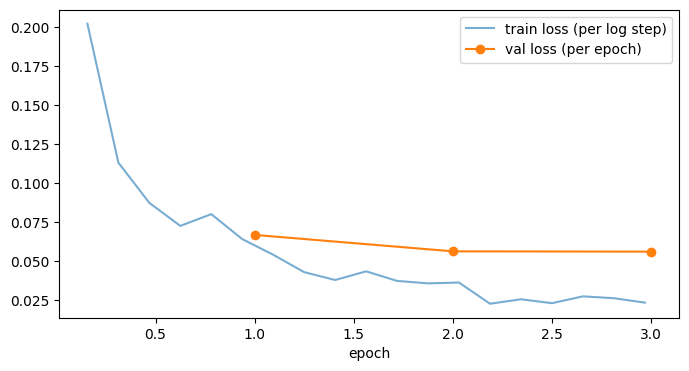

In [9]:
import json, matplotlib.pyplot as plt
from task2_genai.finetune import epoch_loss_table
table = epoch_loss_table(trainer.state.log_history)
print(table.to_string(index=False))
print("validation loss strictly decreasing:", bool((table["val_loss"].diff().dropna() < 0).all()))
steps = pd.DataFrame([h for h in trainer.state.log_history if "loss" in h and "eval_loss" not in h])
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(steps["epoch"], steps["loss"], label="train loss (per log step)", alpha=0.6)
ax.plot(table["epoch"], table["val_loss"], "o-", label="val loss (per epoch)")
ax.set_xlabel("epoch"); ax.legend(); plt.show()
os.makedirs("task2_genai/results", exist_ok=True)
table.to_csv("task2_genai/results/epoch_losses.csv", index=False)
json.dump(trainer.state.log_history, open("task2_genai/results/log_history.json", "w"), indent=1)

## Out-of-memory and error log
**No out-of-memory error occurred.** Peak GPU memory was **7.64 GB of 15.6 GB** on the T4. The reasons are 4-bit NF4 weights with double quantisation (2.81 GB after load), gradient checkpointing, paged 8-bit AdamW, batch size 2 with gradient accumulation 4, and a sequence length set from the data (960 tokens, so nothing is truncated).

**Errors encountered and fixed:**
1. `TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'warmup_ratio'`. Colab installed transformers v5, which removed `warmup_ratio`. Fix: compute an integer `warmup_steps` (5% of 96 steps = 5), which works in v4 and v5. Pulled the fix (first cell) and restarted the session.
2. `ImportError: Found an incompatible version of torchao 0.10.0` during the merge (see below). Colab pre-installs an old torchao, and peft checks for it when loading the adapter onto the fp16 base, although this project never uses torchao. Fix: uninstall torchao and re-run only the merge. The adapter was already saved, so no retraining was needed.

## Save adapters, merge with `merge_and_unload()`, push to the Hub

In [10]:
ADAPTER_DIR, MERGED_DIR = f"{OUT}/adapter", f"{OUT}/merged"
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

from task2_genai.finetune import free_gpu, merge_and_save
del model, trainer
free_gpu()
merge_and_save(cfg, ADAPTER_DIR, MERGED_DIR, tokenizer)
print(os.listdir(MERGED_DIR))

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

ImportError: Found an incompatible version of torchao. Found version 0.10.0, but only versions above 0.16.0 are supported

In [11]:
# Fix: Colab ships torchao 0.10; peft rejects torchao < 0.16 during merge. Not used here, so remove it.
!pip uninstall -y -q torchao
import sys, importlib, gc, torch
sys.modules.pop("torchao", None)
importlib.invalidate_caches()
gc.collect(); torch.cuda.empty_cache()


In [12]:
merge_and_save(cfg, ADAPTER_DIR, MERGED_DIR, tokenizer)
print(os.listdir(MERGED_DIR))

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

['chat_template.jinja', 'tokenizer.json', 'config.json', 'generation_config.json', 'model.safetensors', 'tokenizer_config.json']


In [13]:
from task2_genai.finetune import push_to_hub
CARD = f"""---
base_model: {cfg.base_model}
library_name: transformers
tags: [qlora, finance, risk-extraction]
---
# Qwen2.5-3B risk-factor extractor

QLoRA (4-bit NF4, r={cfg.lora_r}, alpha={cfg.lora_alpha}) fine-tune of {cfg.base_model} that extracts material risk factors from financial-disclosure passages into JSON (12-category taxonomy, severity, affected metric, verbatim evidence quote). Adapters merged with merge_and_unload(). Trained on synthetic passages generated by Llama-family teacher models. Not investment advice.\n"""
url = push_to_hub(MERGED_DIR, HF_REPO_ID, HF_TOKEN, CARD)
print("Model:", url)

Model: https://huggingface.co/Krishan-1890/qwen2.5-3b-risk-extractor


In [14]:
from task2_genai.evaluation import generate, load_for_inference, prompt_messages
test = load_jsonl(DATA_DIR / "test.jsonl")
ft_model, ft_tok = load_for_inference(MERGED_DIR)
out = generate(ft_model, ft_tok, [prompt_messages(test[0])])[0]
print(prompt_messages(test[0])[1]["content"][:600])
print("\nMODEL OUTPUT:\n", out["text"])

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

Document type: sustainability report

Excerpt:
At Fenwick Holdings, our commitment to operational transparency remains paramount as we navigate an increasingly volatile digital landscape. Our primary cloud infrastructure relies heavily on specialized high-performance chipsets sourced from a single vendor, Aethelgard Silicon, which currently fulfills 92% of our server hardware requirements. Any disruption in their fabrication capacity or geopolitical trade barriers affecting their export licenses could force a total suspension of our core SaaS deployment services. While we previously encountere

MODEL OUTPUT:
 {"risks": [{"category": "supply_chain", "severity": "high", "affected_metric": "operating margin", "evidence_quote": "Our primary cloud infrastructure relies heavily on specialized high-performance chipsets sourced from a single vendor, Aethelgard Silicon, which currently fulfills 92% of our server hardware requirements."}, {"category": "esg_climate", "severity": "medium", "affect